In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('placement (for regression).csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

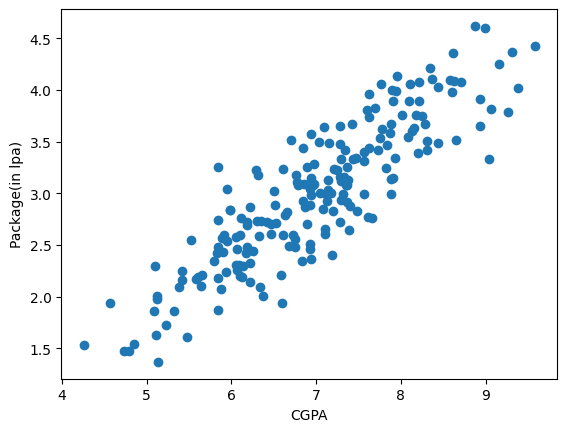

In [5]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [6]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

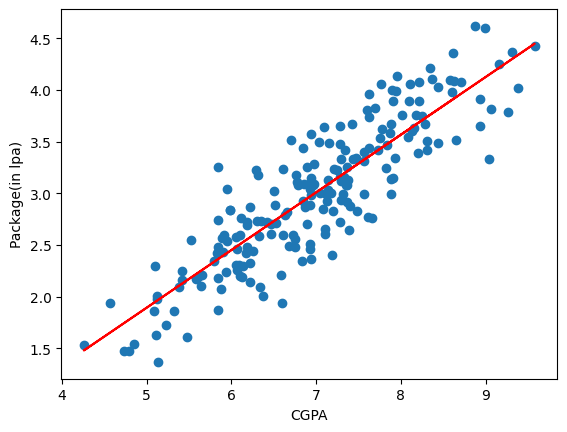

In [8]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [9]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred = lr.predict(X_test)

In [10]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [11]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [12]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [15]:
print("R2 SCORE",r2_score(y_test,y_pred))

R2 SCORE 0.780730147510384




---



---



---

---





#5. ADJUSTED R2 SCORE

In [16]:
r2 = r2_score(y_test,y_pred)

In [18]:
X_test.shape
# TO CALCULATE N VALUE (NO OF ROWS)

(40, 1)

In [20]:
ADJUSTED_R2=1 - ((1-r2)*(40-1)/(40-1-1))
ADJUSTED_R2

0.7749598882343415

# WHEN IRRELEVANT COLUMNS ADD

In [21]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.991191,3.26
1,5.12,0.510074,1.98
2,7.82,0.597801,3.25
3,7.42,0.011094,3.67
4,6.94,0.080913,3.57


Text(0, 0.5, 'Package(in lpa)')

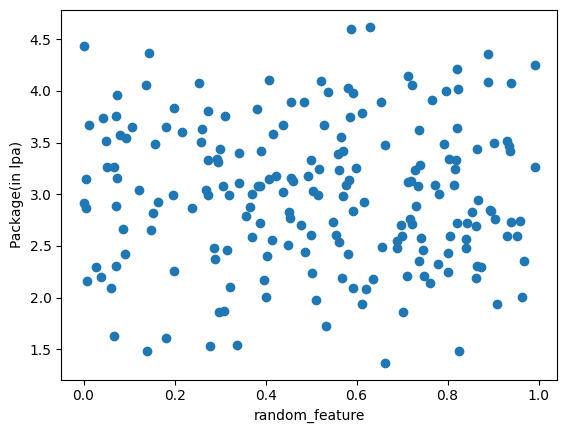

In [22]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [23]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [25]:
y_pred = lr.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
# NOT SIGNIFICANT DIFFERENCE THAN PREVIOUS R2 SCORE

R2 score 0.7798581113004257


In [28]:
ADJUSTED_R2=1 - ((1-r2)*(40-1)/(40-1-2))
ADJUSTED_R2
# IT DECREASE AS COMPARED TO THE PREVIOUS ONE

0.7679585497490974

# WHEN RELEVANT COLUMNS ARE ADDED

In [30]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)
new_df2 = new_df2[['cgpa','iq','package']]
new_df2.sample(5)

,cgpa,iq,package
186,7.84,2.57,3.47
133,6.05,3.68,2.58
22,6.14,3.30,2.30
106,6.13,2.39,2.19
148,7.57,3.10,3.40


Text(0, 0.5, 'Package(in lpa)')

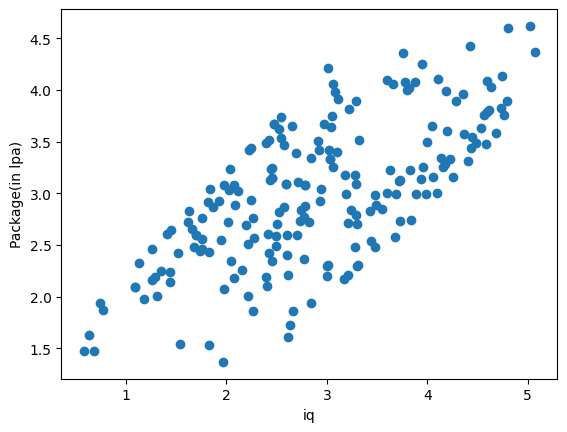

In [31]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [33]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

# SIGNIFICANT INCRESE IN R2 SCORE AS COMPARED TO PREVIOUS ONES

R2 score 0.8365176870440292


In [36]:
ADJUSTED_R2=1 - ((1-r2)*(40-1)/(40-1-2))
ADJUSTED_R2
# IT ALSO INCREASE SIGNIFICANTLY

0.8276808052626253

#**WE USE ADJUSTED R2 SCORE PREFERABLY WHEN IRRELEVANT COLUMNS ARE PRESENT**